In [ ]:
import sys
import os

# Add the absolute path to the `navisim/` directory
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, project_root)

NameError: name 'gaussian_splatting' is not defined

In [ ]:

from navisim.navisim_arena import NavisimArena
from navisim.world.sequence_graph import SequenceGraph
from navisim.envs.navisim_env import NavisimEnv

/lab/student/ziqi/navisim/third_party


AttributeError: module 'gaussian_splatting.arguments' has no attribute 'ModelParams'

In [ ]:
from navisim.data.rocksdb import get_db
db = get_db()

[INFO] RocksDB initialized at: /lab/kiran/navisim-1/assets/rocksdb


In [ ]:
from navisim.utils.visualize import visualize_seq_graph

sequence_graph = SequenceGraph(path='../assets/sequence_graph.gpickle')

In [ ]:
from plyfile import PlyData
import numpy as np

original_path = '/lab/kiran/navisim/haopeng/splat_files/3dgs_train/output/12a18dcf-1/point_cloud/iteration_30000/point_cloud.ply'
new_path = '/lab/kiran/navisim-1/notebooks/gs/2023_03_29/0/sector0/point_cloud/iteration_0/point_cloud.ply'

def load_ply_data(path):
    """Load PLY data and return both field names and structured array."""
    plydata = PlyData.read(path)
    data = plydata.elements[0].data
    return data.dtype.names, data

def assert_ply_equal(path1, path2):
    """Assert that two PLY files have the same fields and values."""
    fields1, data1 = load_ply_data(path1)
    fields2, data2 = load_ply_data(path2)

    assert fields1 == fields2, f"Field mismatch:\n{fields1} != {fields2}"
    assert len(data1) == len(data2), f"Number of rows mismatch: {len(data1)} != {len(data2)}"

    for name in fields1:
        arr1 = data1[name]
        arr2 = data2[name]

        if np.issubdtype(arr1.dtype, np.floating):
            assert np.allclose(arr1, arr2, atol=1e-6), f"Mismatch in field '{name}'"
        else:
            assert np.array_equal(arr1, arr2), f"Mismatch in field '{name}'"

    print("✅ PLY files match in both structure and values.")

# Usage
assert_ply_equal(original_path, new_path)

✅ PLY files match in both structure and values.


In [ ]:
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

fps_records = []
time_taken_to_load = []

def show_image_in_notebook(pixels, step=None, fps = None): 
    clear_output(wait=True)
    plt.imshow(pixels)
    plt.axis("off")
    fps_records.append(fps)
    if step is not None:
        plt.title(f"Step {step}" + f'({fps:.2f} fps)' if fps else '')
    plt.show()
    plt.pause(0.5) 

In [ ]:
num_steps =20

from navisim.enums.enums import RenderMode
from navisim.envs.game_window import GameWindow

import os
os.environ["SDL_VIDEODRIVER"] = "dummy"

window = GameWindow(width = 1280, height=720)
render_mode = RenderMode.NONE
env = NavisimEnv(sequence_graph=sequence_graph, render_mode=render_mode, window=window)

arena = NavisimArena(env = env)
arena.run_episode(num_steps, on_render=show_image_in_notebook)

[INFO] RocksDB closed: /lab/kiran/navisim-1/assets/rocksdb
Loading GaussianSplatting for 2023_03_29/0/sector0
[INFO] RocksDB initialized at: /lab/kiran/navisim-1/assets/rocksdb
Loading trained model at iteration 0


AttributeError: 'GaussianModelParam' object has no attribute 'source_path'

In [ ]:
import pandas as pd
df = pd.read_csv("resource_log.csv")
df.columns


Index(['timestamp', 'render_step', 'render_fps', 'render_time_s',
       'cpu_percent', 'memory_percent', 'memory_used_MB', 'memory_total_MB',
       'gpu_id', 'gpu_name', 'gpu_load_percent', 'gpu_mem_used_MB',
       'gpu_mem_free_MB', 'gpu_temp_C'],
      dtype='object')

In [ ]:
import matplotlib.pyplot as plt

'''
GPU Load % and Memory Used
'''
gpu_df = df[df['gpu_id'] == 0]
gpu_df.head()


,timestamp,render_step,render_fps,render_time_s,cpu_percent,memory_percent,memory_used_MB,memory_total_MB,gpu_id,gpu_name,gpu_load_percent,gpu_mem_used_MB,gpu_mem_free_MB,gpu_temp_C
0,2025-06-10 19:30:10,0,193.276992,0.005174,4.5,9.8,5570,64193,0,NVIDIA GeForce RTX 2080 Ti,7.0,1417.0,9592.0,27.0
1,2025-06-10 19:30:11,1,66.557238,0.015025,20.2,9.8,5572,64193,0,NVIDIA GeForce RTX 2080 Ti,2.0,1577.0,9432.0,27.0
2,2025-06-10 19:30:11,2,124.837907,0.008010,7.2,9.8,5580,64193,0,NVIDIA GeForce RTX 2080 Ti,2.0,1577.0,9432.0,27.0
3,2025-06-10 19:30:12,3,72.907647,0.013716,20.1,9.8,5582,64193,0,NVIDIA GeForce RTX 2080 Ti,0.0,1577.0,9432.0,27.0
4,2025-06-10 19:30:13,4,122.946035,0.008134,7.3,9.8,5586,64193,0,NVIDIA GeForce RTX 2080 Ti,1.0,1577.0,9432.0,27.0


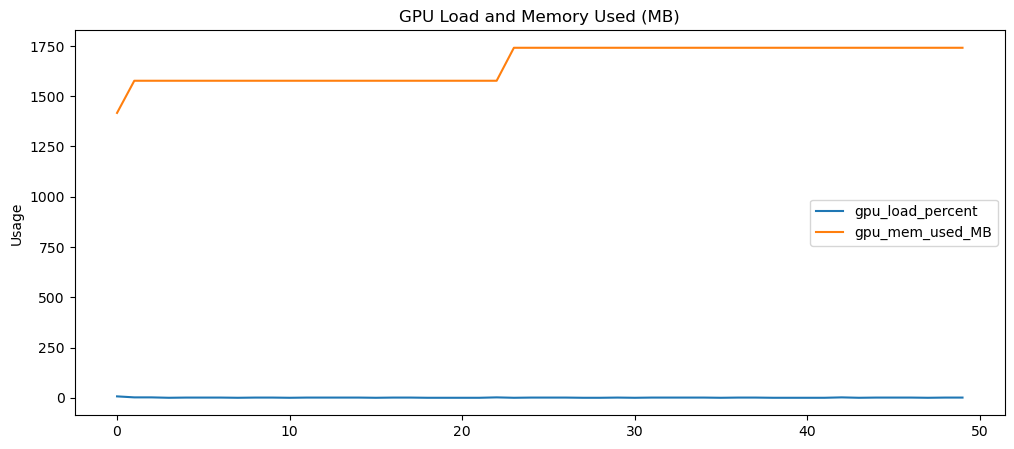

In [ ]:
gpu_df[['gpu_load_percent', 'gpu_mem_used_MB']].plot(
    title="GPU Load and Memory Used (MB)",
    figsize=(12, 5)
)
plt.ylabel("Usage")
plt.show()

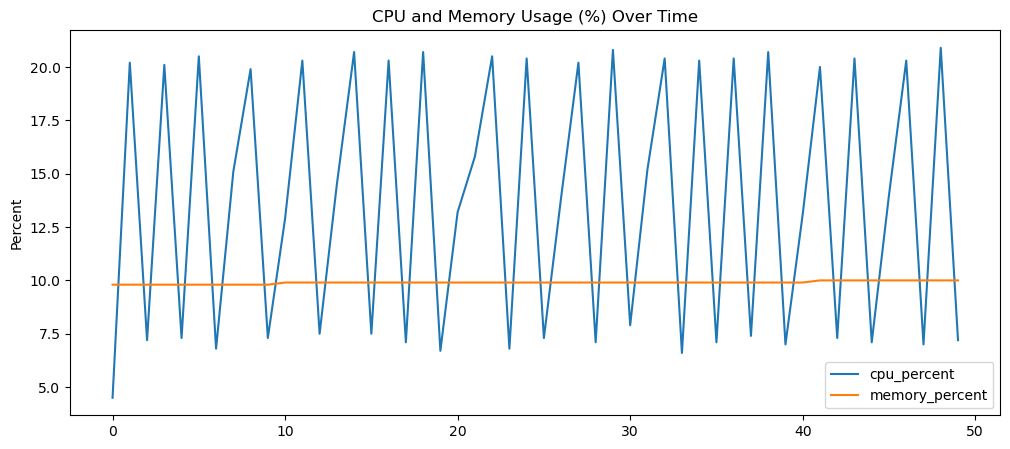

In [ ]:
'''
CPU And RAM Usage Over Time
'''
df[['cpu_percent', 'memory_percent']].plot(
    title="CPU and Memory Usage (%) Over Time",
    figsize=(12, 5)
)
plt.ylabel("Percent")
plt.show()

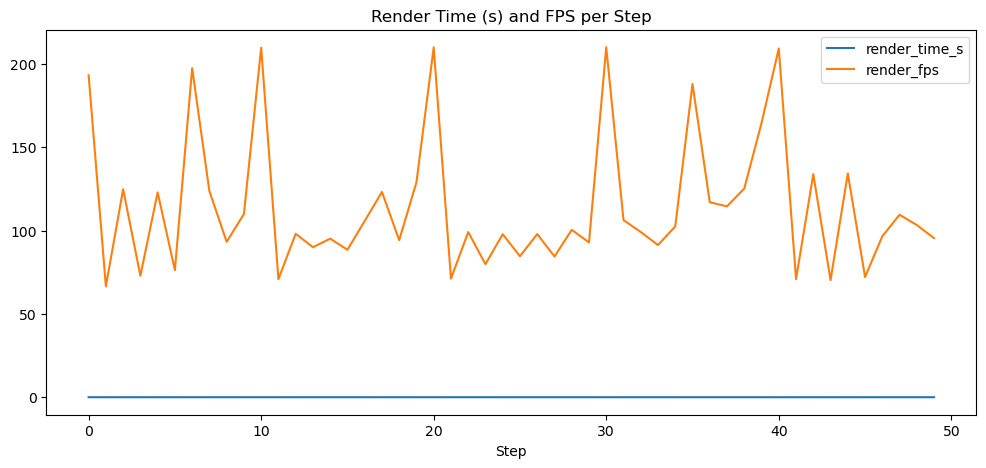

Average Render Time per Step: 0.0097 s
Average FPS: 114.39


In [ ]:
'''
Render Time and FPS per Step
'''
df[['render_step', 'render_time_s', 'render_fps']].plot(
    x='render_step',
    y=['render_time_s', 'render_fps'],
    title="Render Time (s) and FPS per Step",
    figsize=(12, 5)
)
plt.xlabel("Step")
plt.show()

avg_render_time = df['render_time_s'].mean()
avg_fps = df['render_fps'].mean()

print(f"Average Render Time per Step: {avg_render_time:.4f} s")
print(f"Average FPS: {avg_fps:.2f}")